# Sensitivity analysis

Two different tools, not one: Gurobi's native post-optimality attributes (shadow prices,
objective-coefficient ranging), which are exact and need only one solve, plus a small
grid sweep for the bigger "what if this cost doubled" questions that fall outside what
local ranging can answer. Uses `src/optimization/model_b.py`, same MILP as notebooks 06/07.

In [1]:
import sys
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
from src.optimization.model_b import load_base_parameters, solve_model_b, extract_results

## Base case

In [2]:
base_params = load_base_parameters()
base_model, base_vars = solve_model_b(base_params)

print("base total cost:", round(base_model.ObjVal, 2))

Restricted license - for non-production use only - expires 2027-11-29


base total cost: 84286.66


## Shadow prices (Gurobi native)

Standard LP duals are not valid for a MILP directly. `Model.fixed()` returns a continuous
copy with every binary `y` fixed at its solved value, a genuine LP for that plan, which can
be re-solved to get valid shadow prices and objective-coefficient ranges.

In [3]:
fixed_model = base_model.fixed()
fixed_model.optimize()

print("fixed LP cost:", round(fixed_model.ObjVal, 2), "(should match base)")

fixed LP cost: 84286.66 (should match base)


In [4]:
capacity_constrs = [c for c in fixed_model.getConstrs() if c.ConstrName.startswith("machine_capacity")]
shadow_prices = pd.DataFrame(
    [{"constraint": c.ConstrName, "shadow_price": c.Pi} for c in capacity_constrs]
)
shadow_prices = shadow_prices[shadow_prices["shadow_price"] != 0]
print("binding capacity constraints:", len(shadow_prices))

binding capacity constraints: 37


In [5]:
parsed = shadow_prices["constraint"].str.extract(r"\[(?P<machine_id>\w+),(?P<t>\d+)\]")
shadow_prices = pd.concat([parsed, shadow_prices], axis=1)
shadow_prices["t"] = shadow_prices["t"].astype(int)
shadow_prices.sort_values("shadow_price").head(10)

,machine_id,t,constraint,shadow_price
4,M01,5,"machine_capacity[M01,5]",-60.500000
3,M01,4,"machine_capacity[M01,4]",-59.300000
2,M01,3,"machine_capacity[M01,3]",-58.100000
1,M01,2,"machine_capacity[M01,2]",-56.900000
27,M03,4,"machine_capacity[M03,4]",-9.480000
26,M03,3,"machine_capacity[M03,3]",-9.283333
25,M03,2,"machine_capacity[M03,2]",-9.086667
36,M04,1,"machine_capacity[M04,1]",-8.334375
10,M01,11,"machine_capacity[M01,11]",-6.000000
9,M01,10,"machine_capacity[M01,10]",-4.800000


**Reading this**: a shadow price of -60 on `M01, t=5` means one more hour of M01 capacity
that week would lower total cost by about $60, the exact dollar value of relaxing that
specific bottleneck, no re-solving needed.

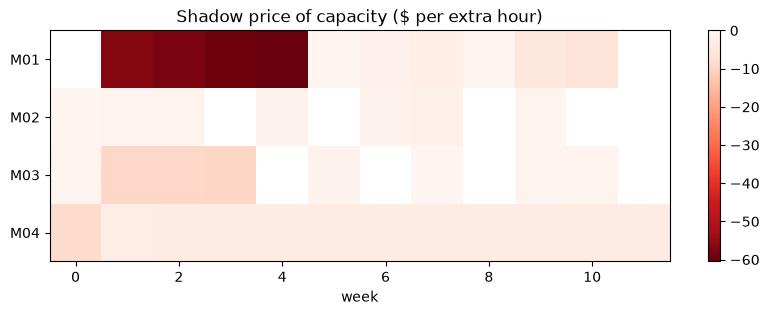

In [6]:
pivot = shadow_prices.pivot(index="machine_id", columns="t", values="shadow_price")

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(pivot.values, aspect="auto", cmap="Reds_r", vmax=0)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("week")
ax.set_title("Shadow price of capacity ($ per extra hour)")
fig.colorbar(im, ax=ax)
plt.show()

## Objective coefficient ranging: production cost

How much each product's `production_cost` could move, up or down, before the current plan
would stop being optimal.

In [7]:
x_vars = [v for v in fixed_model.getVars() if v.VarName.startswith("x[") and v.X > 1e-6]
ranging = pd.DataFrame(
    [{"var": v.VarName, "obj": v.Obj, "low": v.SAObjLow, "up": v.SAObjUp} for v in x_vars]
)
ranging["product_id"] = ranging["var"].str.extract(r"x\[(\w+),")
ranging.head()

,var,obj,low,up,product_id
0,"x[P01,M01,1]",1.19,1.190,1.198417,P01
1,"x[P01,M01,2]",1.19,0.228,2.323000,P01
2,"x[P01,M01,3]",1.19,0.252,2.342000,P01
3,"x[P01,M01,4]",1.19,0.276,2.376000,P01
4,"x[P01,M01,5]",1.19,0.300,2.385556,P01


In [8]:
range_by_product = ranging.groupby("product_id").agg(
    production_cost=("obj", "first"), low=("low", "max"), up=("up", "min")
).round(3)
range_by_product

,production_cost,low,up
product_id,,,
P01,1.19,1.190,1.190
P02,0.73,0.730,0.730
P03,2.93,2.929,2.931
P04,7.48,-inf,7.480
P05,0.73,0.727,0.730
P06,2.88,2.879,2.881
P07,4.88,-inf,4.880
P08,0.36,-0.188,0.628
P09,3.81,3.810,3.810


## Grid sweep: bigger cost swings

Local ranging above only covers small moves around the current basis. For "what if this
cost changed by 20%" questions, re-solve directly.

In [9]:
def scale_dict(d, factor):
    return {k: v * factor for k, v in d.items()}

In [10]:
sweep_rows = []
for factor in [0.8, 1.2]:
    p2 = load_base_parameters(overtime_wage=35 * factor)
    cost = solve_model_b(p2)[0].ObjVal
    sweep_rows.append(("overtime_wage", factor, cost))

In [11]:
for key in ["holding_cost", "setup_cost", "shortage_cost"]:
    for factor in [0.8, 1.2]:
        p2 = dict(base_params)
        p2[key] = scale_dict(base_params[key], factor)
        cost = solve_model_b(p2)[0].ObjVal
        sweep_rows.append((key, factor, cost))

In [12]:
sweep = pd.DataFrame(sweep_rows, columns=["parameter", "factor", "total_cost"])
sweep["delta"] = sweep["total_cost"] - base_model.ObjVal
sweep.round(2)

,parameter,factor,total_cost,delta
0,overtime_wage,0.8,84241.83,-44.83
1,overtime_wage,1.2,84297.05,10.39
2,holding_cost,0.8,84051.27,-235.39
3,holding_cost,1.2,84365.73,79.07
4,setup_cost,0.8,82120.20,-2166.46
5,setup_cost,1.2,86105.48,1818.82
6,shortage_cost,0.8,83159.89,-1126.77
7,shortage_cost,1.2,84355.96,69.30


## Visualization: tornado chart

In [13]:
tornado = sweep.pivot(index="parameter", columns="factor", values="delta")
tornado["swing"] = tornado[1.2] - tornado[0.8]
tornado = tornado.sort_values("swing")
tornado.round(2)

factor,0.8,1.2,swing
parameter,,,
overtime_wage,-44.83,10.39,55.22
holding_cost,-235.39,79.07,314.46
shortage_cost,-1126.77,69.30,1196.07
setup_cost,-2166.46,1818.82,3985.28


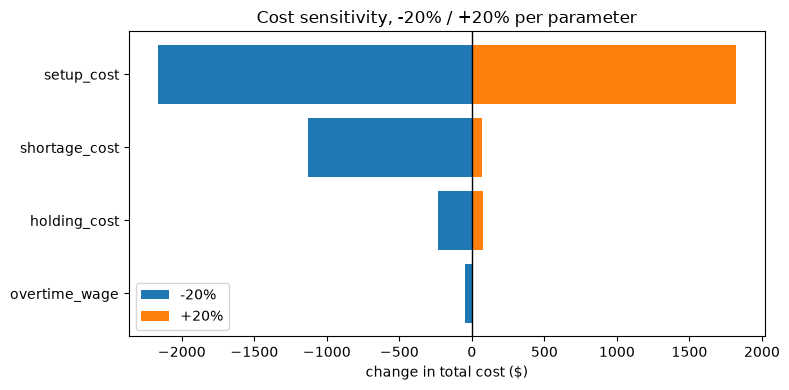

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(tornado.index, tornado[0.8], color="tab:blue", label="-20%")
ax.barh(tornado.index, tornado[1.2], color="tab:orange", label="+20%")
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("change in total cost ($)")
ax.set_title("Cost sensitivity, -20% / +20% per parameter")
ax.legend()
plt.tight_layout()
plt.show()

## Save results

In [15]:
from pathlib import Path
RESULTS_DIR = Path("../results/tables")
sweep.to_csv(RESULTS_DIR / "sensitivity_sweep.csv", index=False)
shadow_prices.to_csv(RESULTS_DIR / "sensitivity_shadow_prices.csv", index=False)
print("Saved sensitivity results to", RESULTS_DIR.resolve())

Saved sensitivity results to C:\Users\HP\Walid\Industrial_production_optimization\results\tables
